## 1. Importação

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Carregando a base PURA que acabamos de exportar do Notebook 1
caminho_dados = '../data/processed/data_model/dados_aed.csv'
df_aed = pd.read_csv(caminho_dados, sep=';')

# 2. Convertendo a data para operações temporais
df_aed['data_inversa'] = pd.to_datetime(df_aed['data_inversa'])

print(f"Base carregada para a AED Pura! Formato: {df_aed.shape}")

Base carregada para a AED Pura! Formato: (208919, 28)


## 2. Periculosidade Média por Rodovia

C:\Users\Computador\AppData\Local\Temp\ipykernel_15580\3222211619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


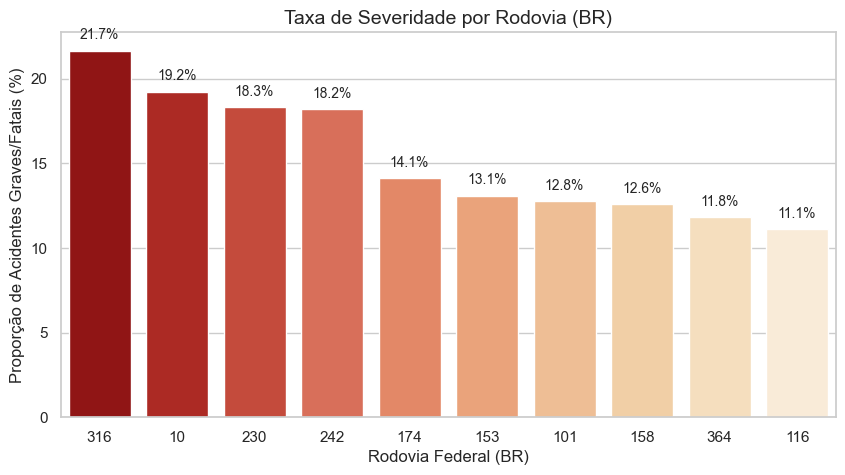

In [2]:
# Calculando a Taxa de Acidentes Graves/Fatais por BR (em %)
periculosidade_br = df_aed.groupby('br')['acidente_grave_ou_fatal'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    x=periculosidade_br.index, 
    y=periculosidade_br.values, 
    order=periculosidade_br.index, 
    palette='OrRd_r'
)

plt.title('Taxa de Severidade por Rodovia (BR)')
plt.ylabel('Proporção de Acidentes Graves/Fatais (%)')
plt.xlabel('Rodovia Federal (BR)')

for i, valor in enumerate(periculosidade_br.values):
    plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()

## 3. Qualidade da Via (ICM) vs. Severidade do Acidente

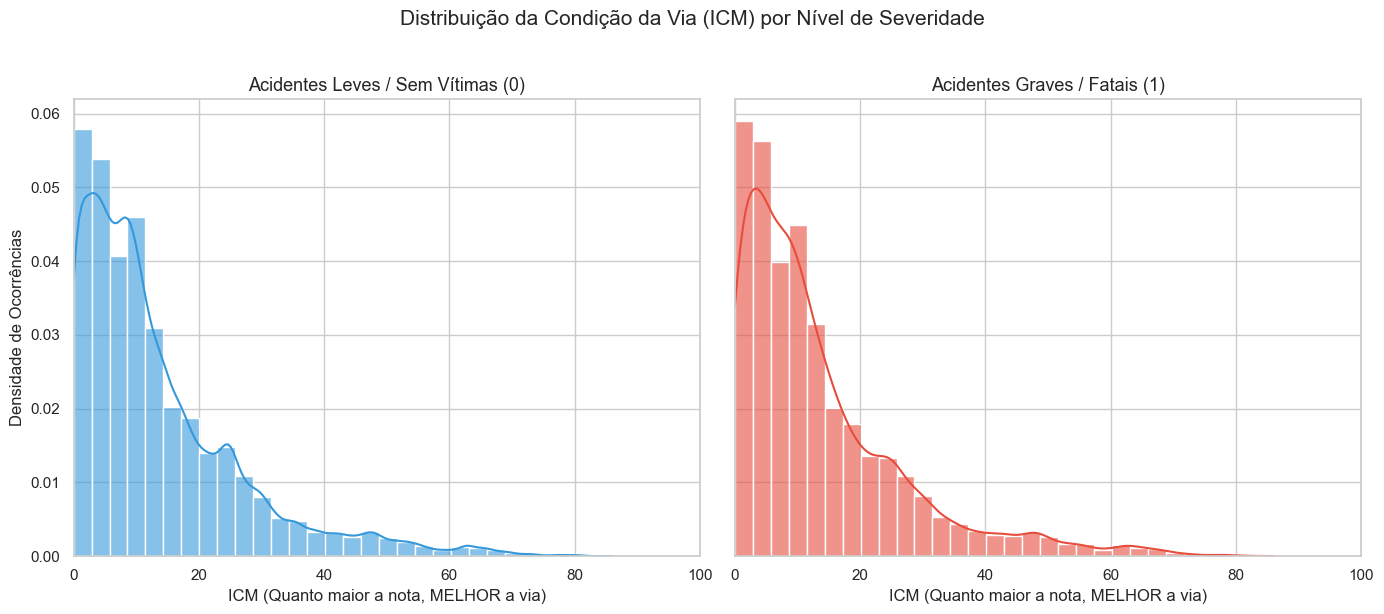

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)

# Painel 1: Ocorrências Leves
sns.histplot(
    data=df_aed[df_aed['acidente_grave_ou_fatal'] == 0], 
    x='icm', color='#3498db', kde=True, bins=30, stat='density', alpha=0.6, ax=axes[0]
)
axes[0].set_title('Acidentes Leves / Sem Vítimas (0)', fontsize=13)
axes[0].set_xlabel('ICM (Quanto maior a nota, MELHOR a via)') # <- Rótulo corrigido
axes[0].set_ylabel('Densidade de Ocorrências')
axes[0].set_xlim(0, 100)

# Painel 2: Ocorrências Graves
sns.histplot(
    data=df_aed[df_aed['acidente_grave_ou_fatal'] == 1], 
    x='icm', color='#e74c3c', kde=True, bins=30, stat='density', alpha=0.6, ax=axes[1]
)
axes[1].set_title('Acidentes Graves / Fatais (1)', fontsize=13)
axes[1].set_xlabel('ICM (Quanto maior a nota, MELHOR a via)') # <- Rótulo corrigido
axes[1].set_ylabel('')

plt.suptitle('Distribuição da Condição da Via (ICM) por Nível de Severidade', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlação Direta: Degradação vs. Periculosidade no Trecho

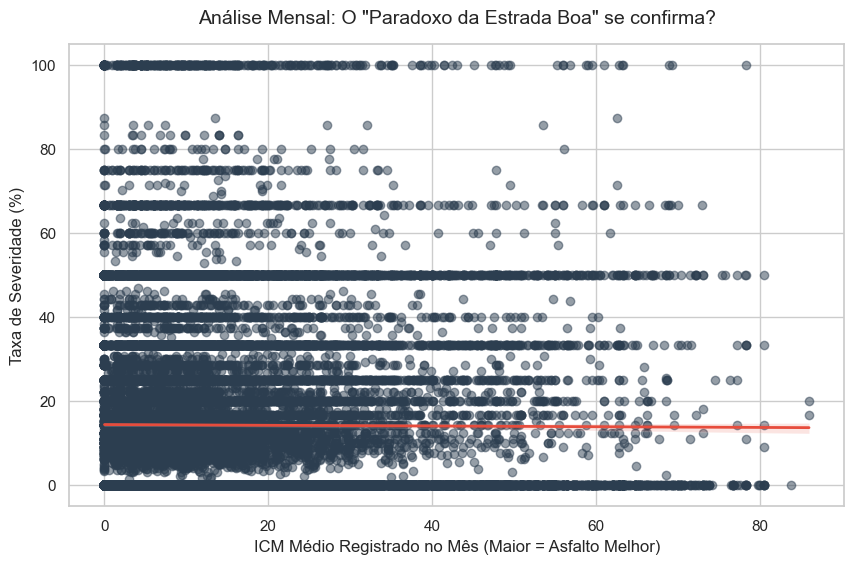

In [4]:

df_aed['ano_mes'] = df_aed['data_inversa'].dt.to_period('M')

# 1. Agrupando por trecho e período mensal
trechos_mensais = df_aed.groupby(['br', 'km_join', 'ano_mes']).agg(
    total_acidentes=('acidente_grave_ou_fatal', 'count'),
    taxa_severidade=('acidente_grave_ou_fatal', 'mean'),
    icm_medio=('icm', 'mean')
).reset_index()

# 2. Filtrando trechos com volume mínimo para evitar ruído estatístico
trechos_criticos = trechos_mensais[trechos_mensais['total_acidentes'] >= 2].copy()
trechos_criticos['taxa_severidade'] = trechos_criticos['taxa_severidade'] * 100

# 3. Plotagem da dispersão com linha de tendência
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(
    data=trechos_criticos, x='icm_medio', y='taxa_severidade',
    scatter_kws={'alpha': 0.5, 'color': '#2c3e50'}, line_kws={'color': '#e74c3c', 'linewidth': 2}
)

plt.title('Análise Mensal: O "Paradoxo da Estrada Boa" se confirma?', pad=15)
plt.xlabel('ICM Médio Registrado no Mês (Maior = Asfalto Melhor)') 
plt.ylabel('Taxa de Severidade (%)')
plt.show()

## 5. Validação Comportamental (Tipo de Acidente vs. ICM)

C:\Users\Computador\AppData\Local\Temp\ipykernel_15580\1846357209.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Computador\AppData\Local\Temp\ipykernel_15580\1846357209.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


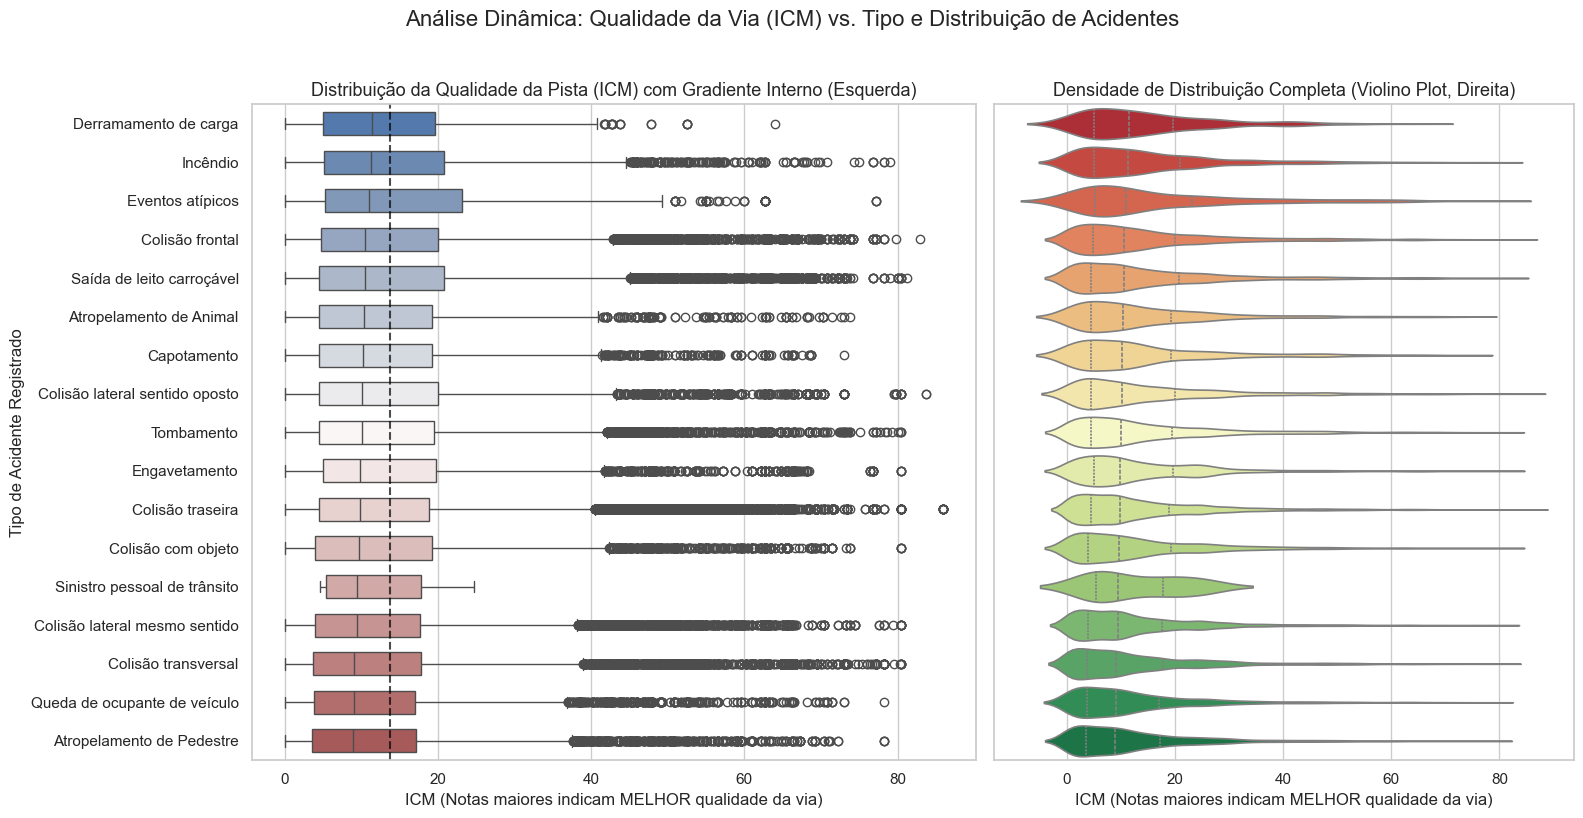

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparação dos dados e ordem
ordem_tipos = df_aed.groupby('tipo_acidente')['icm'].median().sort_values(ascending=False).index

# 2. Configuração do layout composto (1x2)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1.5, 1.2]}, sharey=True)

# --- PAINEL 1: Boxplot com Gradiente Interno (Esquerda, Correção Final) ---
# Usamos uma paleta neutra para os elementos externos; o gradiente será aplicado internamente.
sns.boxplot(
    data=df_aed, 
    x='icm', 
    y='tipo_acidente', 
    order=ordem_tipos, 
    palette='vlag', # Paleta neutra para elementos externos
    width=0.6,
    showmeans=False, # Removendo a média para focar na mediana/distribuição
    ax=axes[0]
)

# Adicionando o gradiente interno de cor em cada caixa (vermelho-verde, esquerda-direita)
for i, artist in enumerate(axes[0].artists):
    # A paleta RdYlGn reflete 'vermelho para ruim, verde para bom'
    cmap = plt.cm.RdYlGn
    
    # Criamos um gradiente interno na caixa (vermelho-amarelo-verde, esquerda-direita)
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))
    
    # Aplicamos a transformação de cor
    im = axes[0].imshow(gradient, aspect='auto', cmap=cmap, extent=artist.get_extents().extents, zorder=0.5)
    
    # Ajustamos a transparência e as bordas para legibilidade
    artist.set_alpha(0.3) # Sutil transparência para sobrepor o gradiente
    artist.set_edgecolor('black')

# Adicionando a linha de referência e títulos do painel 1
media_geral_icm = df_aed['icm'].mean()
axes[0].axvline(x=media_geral_icm, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Distribuição da Qualidade da Pista (ICM) com Gradiente Interno (Esquerda)', fontsize=13)
axes[0].set_xlabel('ICM (Notas maiores indicam MELHOR qualidade da via)')
axes[0].set_ylabel('Tipo de Acidente Registrado')

# --- PAINEL 2: Violino Plot de Densidade (A Nova Adição) ---
# Usamos a mesma paleta RdYlGn (vermelho-verde do topo à base) para os contornos sutis, mostrando a densidade completa.
sns.violinplot(
    data=df_aed, 
    x='icm', 
    y='tipo_acidente', 
    order=ordem_tipos, 
    palette='RdYlGn', 
    width=0.8,
    linewidth=1.2,
    edgecolor='gray',
    inner='quartile', 
    ax=axes[1]
)
axes[1].set_title('Densidade de Distribuição Completa (Violino Plot, Direita)', fontsize=13)
axes[1].set_xlabel('ICM (Notas maiores indicam MELHOR qualidade da via)')
axes[1].set_ylabel('') # Ocultando o eixo Y para o segundo gráfico
axes[1].tick_params(axis='y', labelleft=False) # Escondendo os textos para ficar limpo

# Título geral para a obra toda
plt.suptitle('Análise Dinâmica: Qualidade da Via (ICM) vs. Tipo e Distribuição de Acidentes', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

## 4. CORRELAÇÃO ESPAÇO-TEMPORAL MENSAL: ICM vs. SEVERIDADE

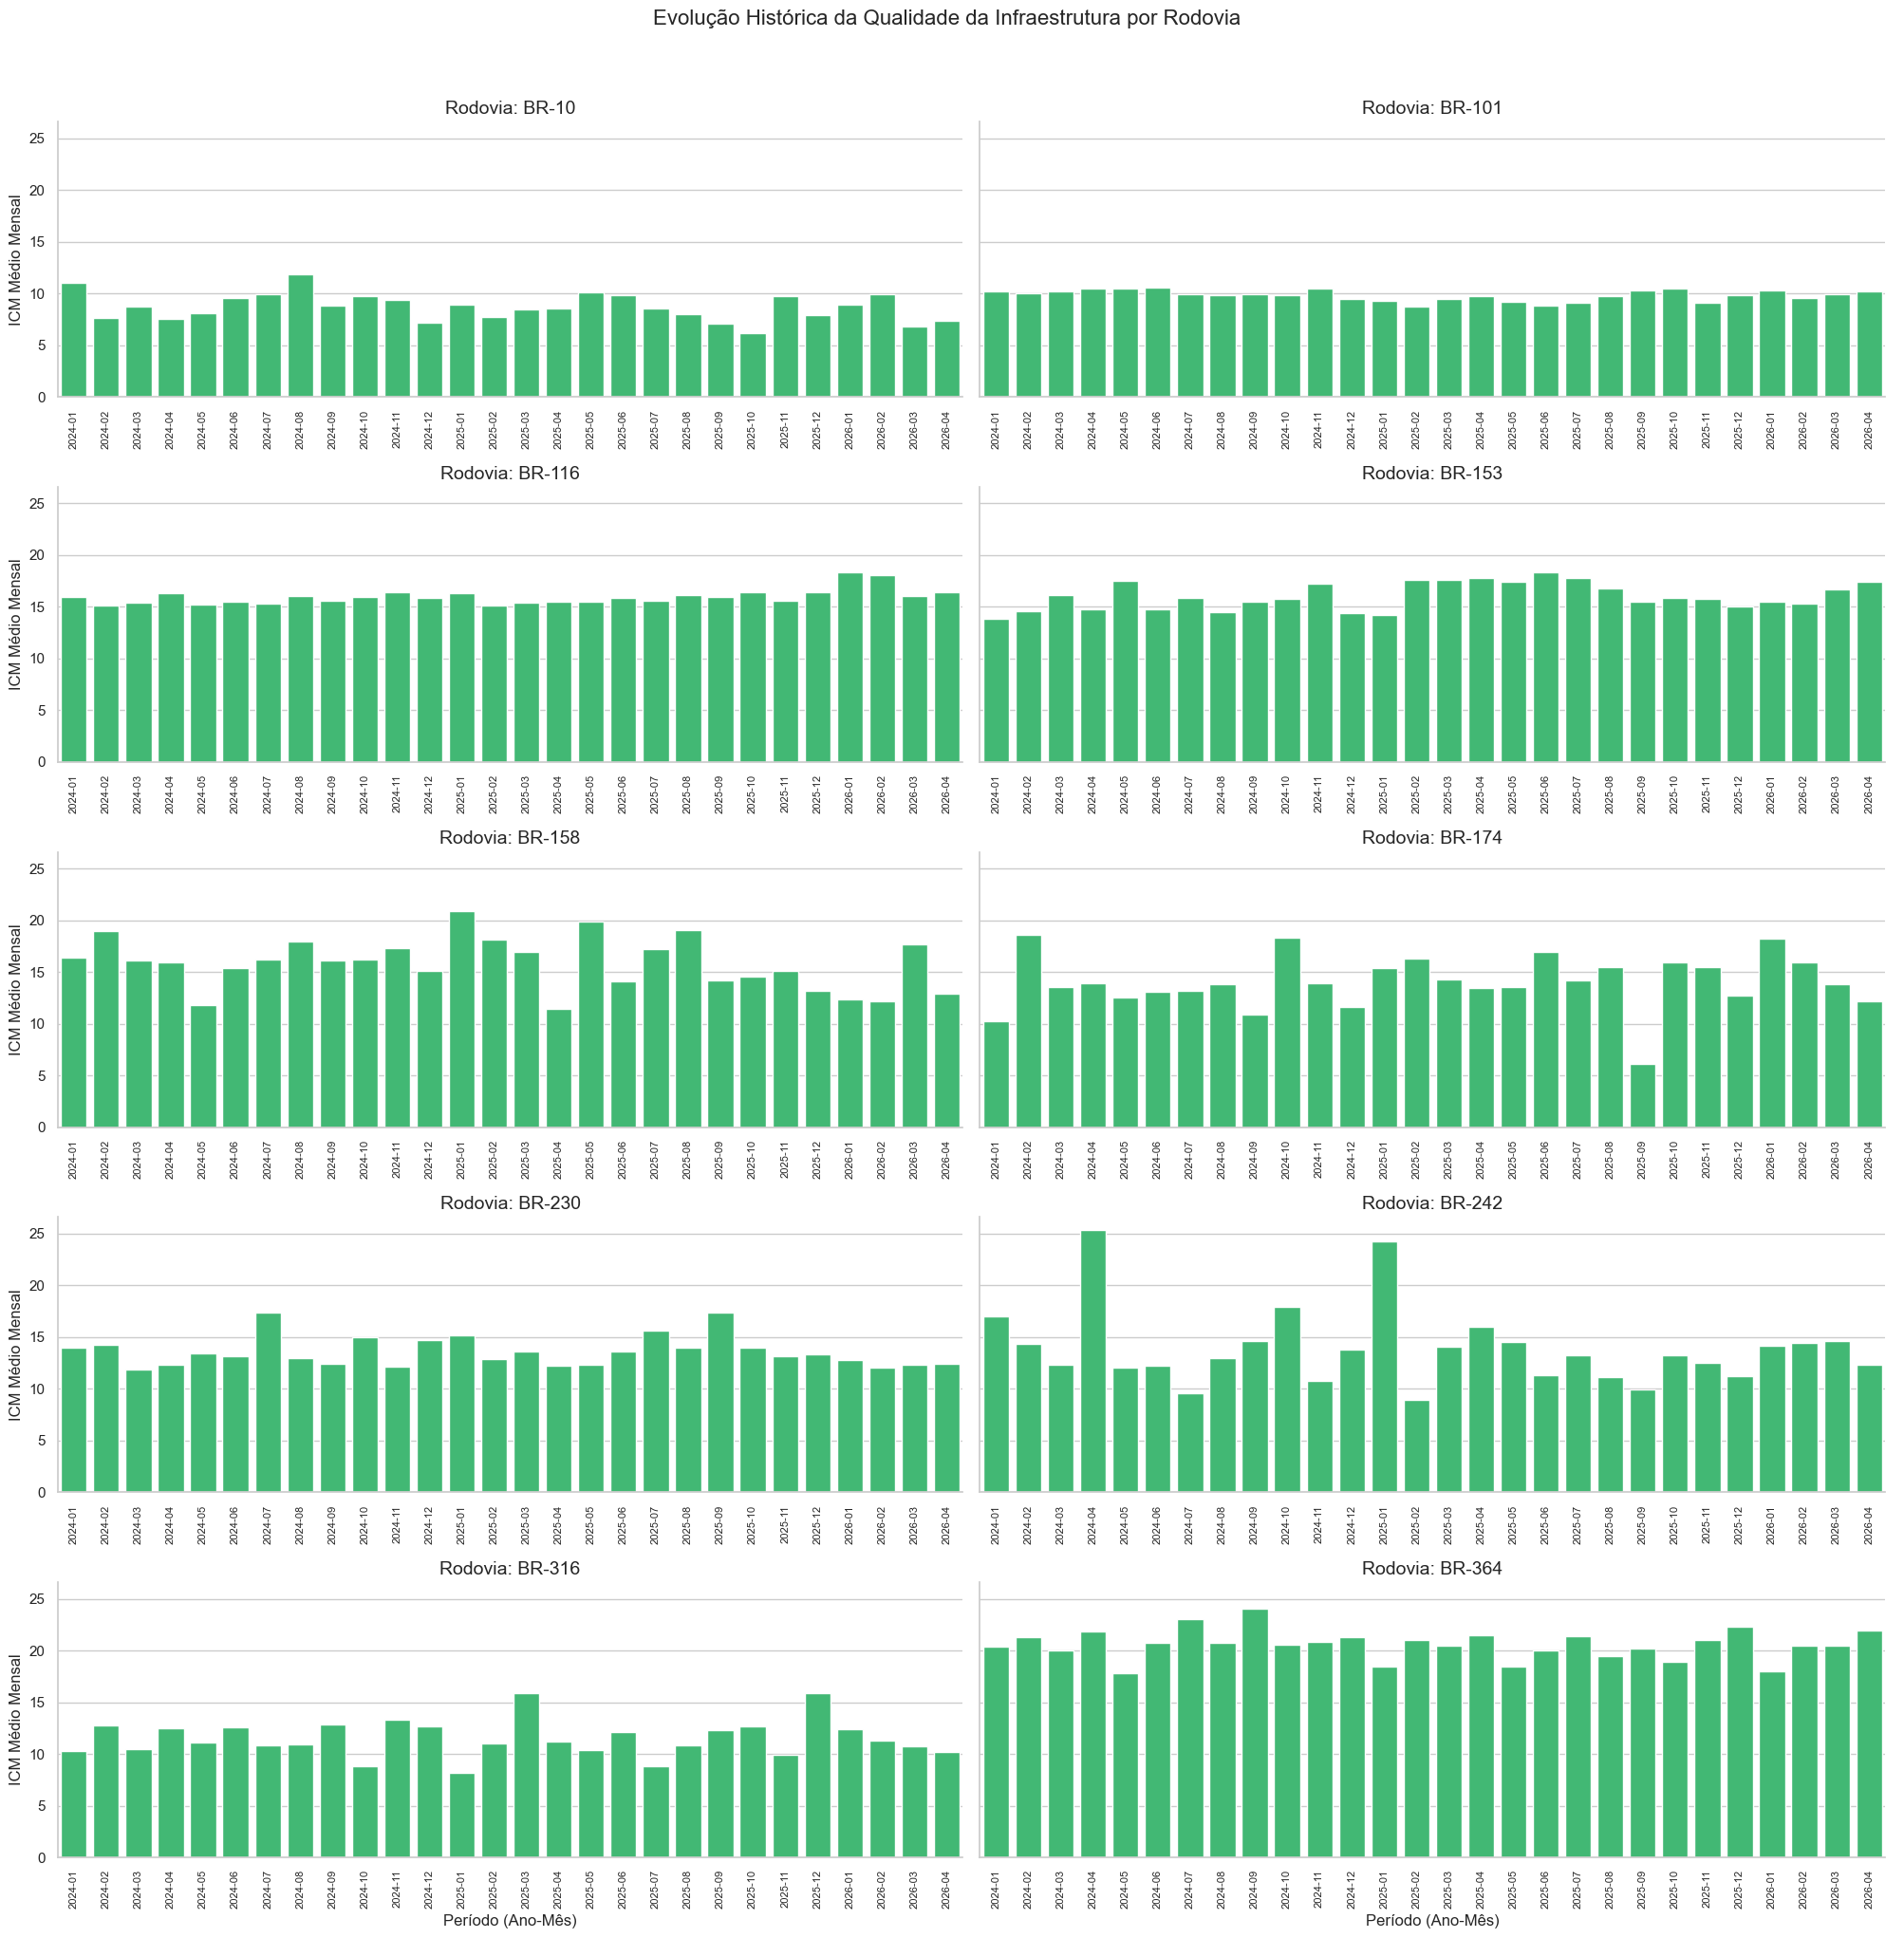

In [6]:
# 1. Calculando a média do ICM por BR e por Mês
evolucao_temporal = df_aed.groupby(['br', 'ano_mes'])['icm'].mean().reset_index()

# Convertendo o período temporal para texto (string). 
# Gráficos de barra categóricos lidam melhor com strings no eixo X.
evolucao_temporal['ano_mes_str'] = evolucao_temporal['ano_mes'].astype(str)

# 2. Criando a grade de gráficos (um painel para cada BR)
# Usamos catplot() do Seaborn, que é perfeito para subdividir dados em vários gráficos menores.
g = sns.catplot(
    data=evolucao_temporal,
    x='ano_mes_str',
    y='icm',
    col='br',           # Cria um gráfico separado para cada BR
    col_wrap=2,         # Coloca 2 gráficos por linha para ficarem largos e legíveis
    kind='bar',
    color='#2ecc71',    # Usando verde como cor base (já que ICM maior = Via Melhor)
    height=4,           # Altura de cada gráfico individual
    aspect=2.5,         # Largura de cada gráfico (2.5 vezes a altura)
    sharex=False        # Permite que cada gráfico mostre apenas os meses com acidentes
)

# 3. Ajustes Estéticos (Títulos e Eixos)
g.set_axis_labels('Período (Ano-Mês)', 'ICM Médio Mensal')
g.set_titles('Rodovia: BR-{col_name}', size=14)

# 4. Ajuste crucial: rotacionando os textos do eixo X em 90 graus para não encavalarem
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_fontsize(8)

# Título geral
plt.suptitle('Evolução Histórica da Qualidade da Infraestrutura por Rodovia', y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

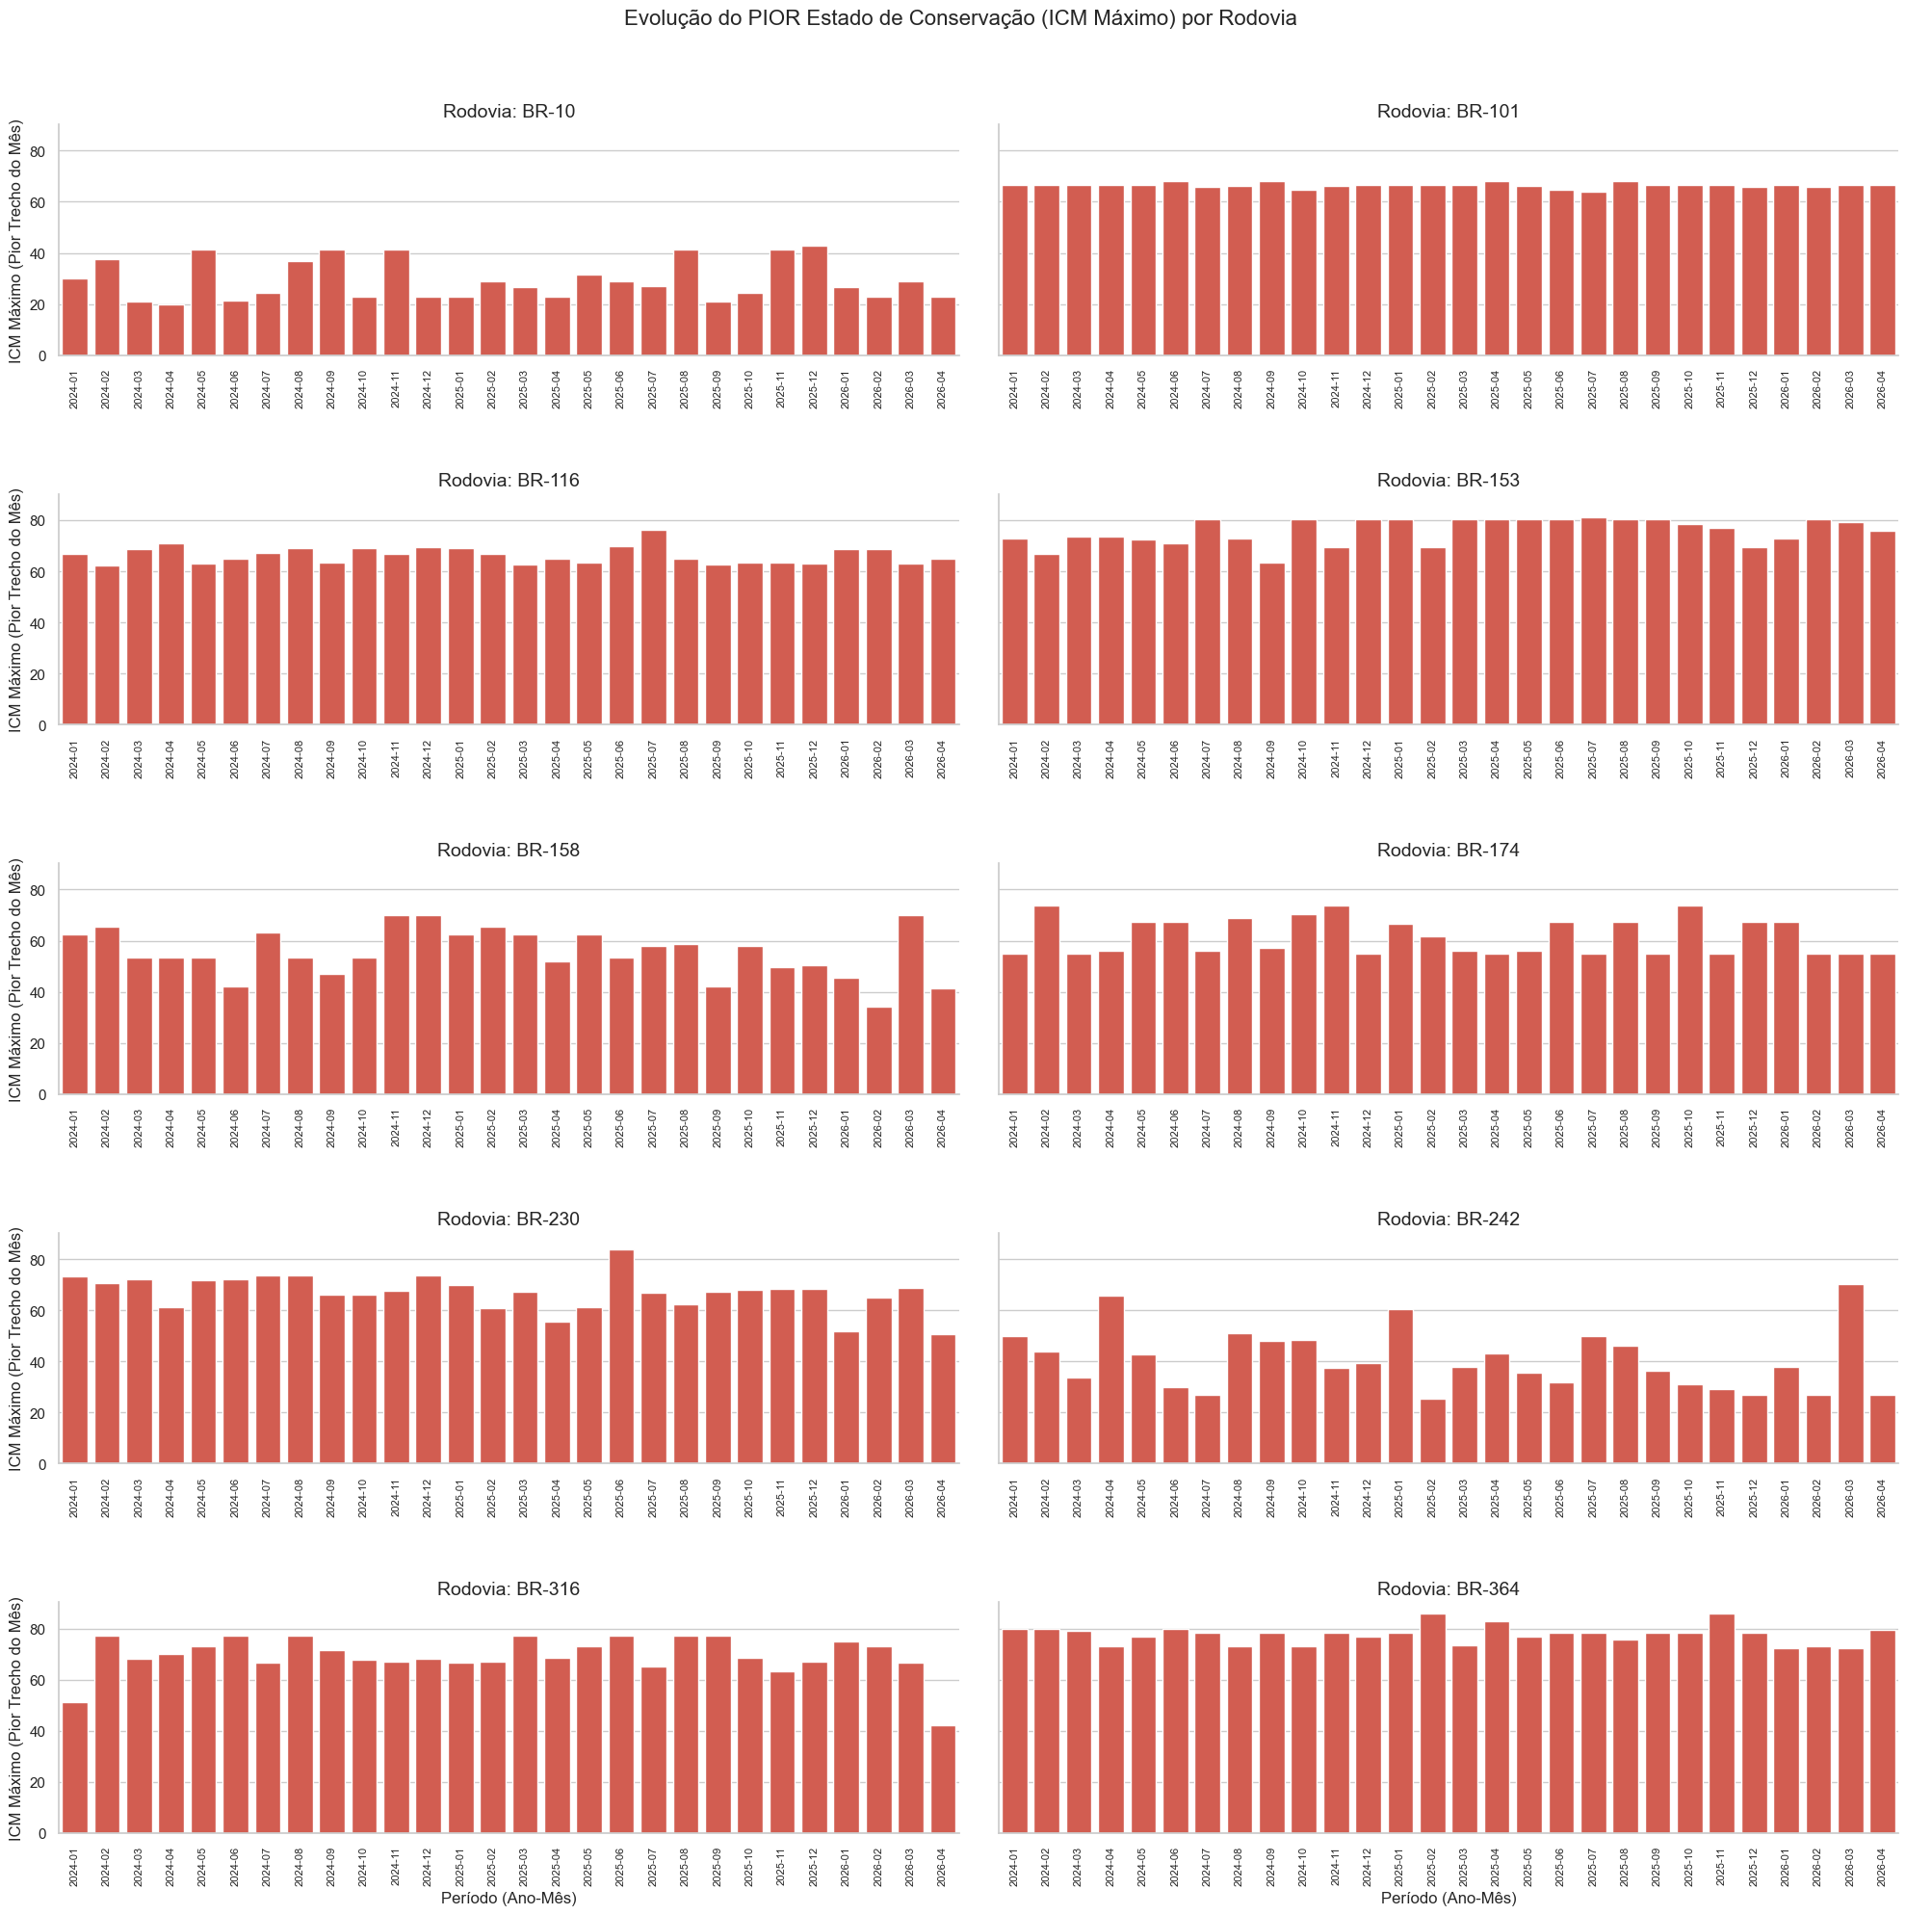

In [7]:
# 1. Trocámos de .mean() para .max() para não esconder os outliers!
# Agora a barra mostra o PIOR estado registado na rodovia naquele mês.
evolucao_temporal = df_aed.groupby(['br', 'ano_mes'])['icm'].max().reset_index()

evolucao_temporal['ano_mes_str'] = evolucao_temporal['ano_mes'].astype(str)

# 2. Criando a grelha de gráficos
g = sns.catplot(
    data=evolucao_temporal,
    x='ano_mes_str',
    y='icm',
    col='br',           
    col_wrap=2,         
    kind='bar',
    color='#e74c3c',    # Mudei para vermelho, já que agora estamos a olhar para o PIOR estado (Alto ICM = Ruim)
    height=4,           
    aspect=2.5,         
    sharex=False        
)

# 3. Ajustes Estéticos (Títulos e Eixos)
g.set_axis_labels('Período (Ano-Mês)', 'ICM Máximo (Pior Trecho do Mês)')
g.set_titles('Rodovia: BR-{col_name}', size=14)

# Rotacionando os textos do eixo X
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_fontsize(8)

# 4. Ajuste de Layout Corrigido (Sem cortar os últimos gráficos)
# Removemos o tight_layout() e usamos isto para dar "respiro" entre as linhas
g.fig.subplots_adjust(top=0.92, hspace=0.6) 

plt.suptitle('Evolução do PIOR Estado de Conservação (ICM Máximo) por Rodovia', fontsize=16)

plt.show()

## 5. Tratamento de Outliers (Capping pelo IQR)

--- Aplicando Capping ---
Coluna ICC: Valor máximo antigo era 100.0 -> Novo teto será 51.9
Coluna ICP: Valor máximo antigo era 90.0 -> Novo teto será 46.2
Coluna ICM: Valor máximo antigo era 86.0 -> Novo teto será 40.9

Outliers suavizados com sucesso. Os dados agora refletem a distribuição real consolidada.


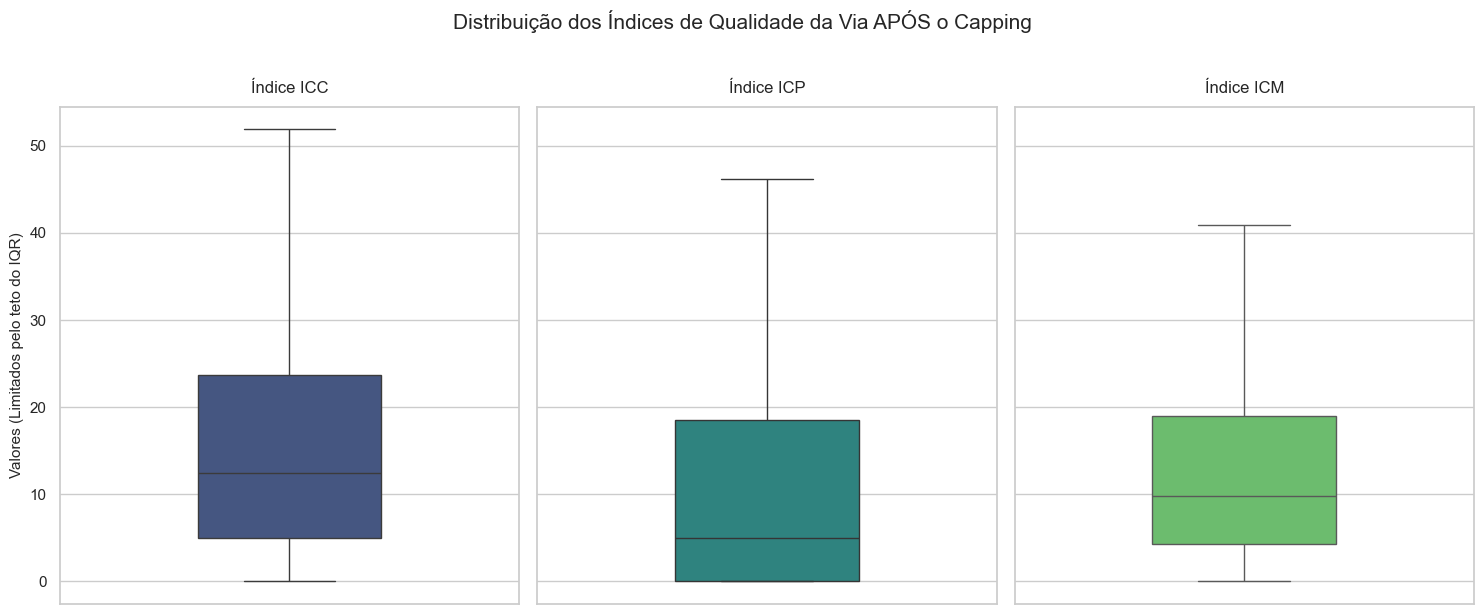

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 7. TRATAMENTO DE OUTLIERS (CAPPING)
# ==========================================
# Justificativa: A exploração visual provou que as médias históricas 
# raramente ultrapassam a marca dos 25 a 30 pontos de ICM. 
# Valores na casa de 80-100 são anomalias extremas ("irreais" com a média).
# Usaremos o método IQR para suavizar o limite superior.

colunas_indices = ['icc', 'icp', 'icm']

print("--- Aplicando Capping ---")
for col in colunas_indices:
    # 1. Calculando os quartis e o intervalo interquartil (IQR)
    Q1 = df_aed[col].quantile(0.25)
    Q3 = df_aed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Definindo o teto máximo aceitável (Limite Superior)
    limite_superior = Q3 + 1.5 * IQR
    
    # Exibindo o corte para acompanhamento
    max_antigo = df_aed[col].max()
    print(f"Coluna {col.upper()}: Valor máximo antigo era {max_antigo:.1f} -> Novo teto será {limite_superior:.1f}")
    
    # 3. Aplicando o capping (tudo acima do limite vira o próprio limite)
    df_aed[col] = df_aed[col].clip(upper=limite_superior)

print("\nOutliers suavizados com sucesso. Os dados agora refletem a distribuição real consolidada.")

# ==========================================
# VISUALIZAÇÃO PÓS-CAPPING (Boxplots Separados)
# ==========================================
# Criando uma figura com 3 gráficos lado a lado (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

cores = sns.color_palette("viridis", 3)

for i, col in enumerate(colunas_indices):
    # Gerando o boxplot vertical individual para cada coluna
    sns.boxplot(
        y=df_aed[col], 
        ax=axes[i], 
        color=cores[i],
        width=0.4
    )
    
    # Ajustes estéticos de cada painel
    axes[i].set_title(f'Índice {col.upper()}', fontsize=12, pad=10)
    axes[i].set_xlabel('')
    
    # Colocando o rótulo do eixo Y apenas no primeiro gráfico para ficar limpo
    if i == 0:
        axes[i].set_ylabel('Valores (Limitados pelo teto do IQR)', fontsize=11)
    else:
        axes[i].set_ylabel('')

plt.suptitle('Distribuição dos Índices de Qualidade da Via APÓS o Capping', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. EXPORTAÇÃO DO DATASET PARA MODELAGEM

In [9]:
import os

# ==========================================
# 8. EXPORTAÇÃO DO DATASET PARA MODELAGEM
# ==========================================

# 1. Definindo o caminho e o nome final do arquivo
pasta_destino = '../data/processed/data_model'
nome_arquivo = 'dados_model.csv'
caminho_completo = os.path.join(pasta_destino, nome_arquivo)

# 2. Garantindo que a pasta existe
os.makedirs(pasta_destino, exist_ok=True)

# 3. Verificando e deletando arquivo anterior (se existir) para evitar conflitos
if os.path.exists(caminho_completo):
    os.remove(caminho_completo)
    print(f"⚠️ Arquivo anterior '{nome_arquivo}' substituído.")

# 4. Exportação do dataframe atualizado (agora com o Capping)
df_aed.to_csv(caminho_completo, index=False, sep=';')

print(f"✅ Sucesso absoluto! Dataset final exportado em: '{caminho_completo}'")
print("A Análise Exploratória está concluída. O arquivo para o modelo foi gerado com sucesso!")

✅ Sucesso absoluto! Dataset final exportado em: '../data/processed/data_model\dados_model.csv'
A Análise Exploratória está concluída. O arquivo para o modelo foi gerado com sucesso!
